Przetwarzanie strumieni danych Oliwia Borkowska lista 8 

Spektogram - graficzne przedstawienie zmiany widma częstotliwości sygnału w czasie
Zad 1. Przygotuj kod w Pythonie, który wygeneruje spektrogramy dla sygnałów z zadania 1 na liście 1: 

a) Sinus
b) Prostokątny
c) Piłokształtny
d) Świergotliwy
e) Superpozycja funkcji sinus i cosinus z samodzielnie dobranymi parametrami
f) Impuls jednostkowy

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

def plot_sygnal_i_spektogram(sig, fs, title):
    t = np.linspace(0, len(sig) / fs, len(sig))
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# sygnał
    axs[0].plot(t, sig, color='magenta')
    axs[0].set_title(f"Sygnał - {title}")
    axs[0].set_xlabel("Czas [s]")
    axs[0].set_ylabel("Amplituda")
    axs[0].grid(True)
#  spektrogram
    axs[1].specgram(sig, Fs=fs, NFFT=256, noverlap=128, cmap='viridis')
    axs[1].set_title(f"Spektrogram - {title}")
    axs[1].set_xlabel("Czas [s]")
    axs[1].set_ylabel("Częstotliwość [Hz]")

    plt.tight_layout()
    plt.show()

# a) Sinus
@interact(f=FloatSlider(min=1, max=1000, step=1, value=50, description='Częstotliwość [Hz]'),
          A=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='Amplituda'))
def sinusoidalny(f, A):
    fs = 5000
    t = np.linspace(0, 1, fs)
    sin = A * np.sin(2 * np.pi * f * t)
    plot_sygnal_i_spektogram(sin, fs, "Sinusoida")

# b) Prostokątny
@interact(f=FloatSlider(min=1, max=500, step=1, value=10, description='Częstotliwość [Hz]'),
          duty=FloatSlider(min=0.1, max=0.9, step=0.1, value=0.5, description='Wsp. wypełnienia'))
def prostokątny(f, duty):
    fs = 5000
    t = np.linspace(0, 1, fs)
    prostokat = signal.square(2 * np.pi * f * t, duty)
    plot_sygnal_i_spektogram(prostokat, fs, "Fala prostokątna")

# c) Piłokształtny
@interact(f=FloatSlider(min=1, max=500, step=1, value=10, description='Częstotliwość [Hz]'))
def piłokształtny(f):
    fs = 5000
    t = np.linspace(0, 1, fs)
    piła = signal.sawtooth(2 * np.pi * f * t)
    plot_sygnal_i_spektogram(piła, fs, "Fala piłokształtna")

# d) Świergotliwy (chirp)
@interact(f0=FloatSlider(min=1, max=100, step=1, value=20, description='f0 [Hz]'),
          f1=FloatSlider(min=100, max=1000, step=10, value=500, description='f1 [Hz]'))
def świergotliwy(f0, f1):
    fs = 5000
    t = np.linspace(0, 1, fs)
    świergot = signal.chirp(t, f0=f0, f1=f1, t1=1, method='linear')
    plot_sygnal_i_spektogram(świergot, fs, "Świergot")

# e) Superpozycja sinusa i cosinusa
@interact(f1=FloatSlider(min=1, max=500, step=1, value=50, description='f1 [Hz]'),
          f2=FloatSlider(min=1, max=500, step=1, value=120, description='f2 [Hz]'),
          A1=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='A1'),
          A2=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='A2'))
def superpozycja(f1, f2, A1, A2):
    fs = 5000
    t = np.linspace(0, 1, fs)
    superpoz = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.cos(2 * np.pi * f2 * t)
    plot_sygnal_i_spektogram(superpoz, fs, "Superpozycja sinus i cosinus")

# f) Impuls jednostkowy
@interact(n=IntSlider(min=1, max=5000, step=1, value=2500, description='Pozycja impulsu'))
def jednostkowy(n):
    fs = 5000
    jednostk = np.zeros(fs)
    if 0 <= n < fs:
        jednostk[n] = 1.0
    plot_sygnal_i_spektogram(jednostk, fs, "Impuls jednostkowy")

interactive(children=(FloatSlider(value=50.0, description='Częstotliwość [Hz]', max=1000.0, min=1.0, step=1.0)…

interactive(children=(FloatSlider(value=10.0, description='Częstotliwość [Hz]', max=500.0, min=1.0, step=1.0),…

interactive(children=(FloatSlider(value=10.0, description='Częstotliwość [Hz]', max=500.0, min=1.0, step=1.0),…

interactive(children=(FloatSlider(value=20.0, description='f0 [Hz]', min=1.0, step=1.0), FloatSlider(value=500…

interactive(children=(FloatSlider(value=50.0, description='f1 [Hz]', max=500.0, min=1.0, step=1.0), FloatSlide…

interactive(children=(IntSlider(value=2500, description='Pozycja impulsu', max=5000, min=1), Output()), _dom_c…

EMD - Empirical Mode Decomposition - proces rozbijający sygnały w komponenty - intrinsic mode functions (IMF). Każdy IMF zawiera najwyższą wartość częstotliwości sygnały w poprzedniej iteracji i pozwala na odrzycenie wysoko-częstotliwościowych zakłóceń. 
Zad 2. Przygotuj w Pythonie kod bazując na pakiecie emd, który dokona dekompozycji sygnału świergotliwego (chirp) oraz wyznaczy widmo każdej mody.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from PyEMD import EMD
from ipywidgets import interact, IntSlider


fs = 1000
t = np.linspace(0, 1, fs)
sygnal_świergotliwy = signal.chirp(t, f0=20, f1=400, t1=1, method='linear')

emd = EMD()
IMFs = emd.emd(sygnal_świergotliwy)
n_imfs = IMFs.shape[0]

def pokaz_imf(i):
    imf = IMFs[i]
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    axs[0].plot(t, imf, color="skyblue")
    axs[0].set_title(f"Moda {i+1}")
    axs[0].set_xlabel("Czas [s]")
    axs[0].set_ylabel("Amplituda")
    
    freqs = np.fft.rfftfreq(len(imf), 1/fs)
    fft_vals = np.abs(np.fft.rfft(imf))
    axs[1].plot(freqs, fft_vals)
    axs[1].set_title(f"Widmo mody {i+1}") # wykres widma pokazuje jakie częstotliwości dominują w danej modzie
    axs[1].set_xlabel("Częstotliwość [Hz]")
    axs[1].set_ylabel("Amplituda")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

interact(pokaz_imf, i=IntSlider(min=0, max=n_imfs-1, step=1, value=0, description='Moda IMF'));


interactive(children=(IntSlider(value=0, description='Moda IMF', max=7), Output()), _dom_classes=('widget-inte…

Zad 3. Zad. 3 Przygotuj w Pythonie kod bazując na pakiecie emd, który dokona dekompozycji dowolnie zbudowanego sygnału będącego superpozycją kilku funkcji sinus i cosinus. Wyznacz widmo każdej z mod.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from ipywidgets import interact, interactive_output, IntSlider, FloatSlider, VBox, HBox, Button, Output, Layout
import ipywidgets as widgets
from IPython.display import display, clear_output

fs = 1000
t = np.linspace(0, 1, fs)

def generuj_sygnal(num_sin, num_cos, params):
    sig = np.zeros_like(t)
    for i in range(num_sin):
        A = params[f'A_sin{i+1}']
        f = params[f'f_sin{i+1}']
        sig += A * np.sin(2 * np.pi * f * t)
    for j in range(num_cos):
        A = params[f'A_cos{j+1}']
        f = params[f'f_cos{j+1}']
        sig += A * np.cos(2 * np.pi * f * t)
    return sig

def analizuj_sygnal(sig):
    emd = EMD()
    IMFs = emd.emd(sig, t)
    n_imfs = IMFs.shape[0]

    fig, axs = plt.subplots(n_imfs+1, 2, figsize=(14, 2.5*(n_imfs+1)))
    axs[0, 0].plot(t, sig, color='magenta')
    axs[0, 0].set_title("Sygnał: superpozycja sinusa i cosinusa")
    axs[0, 0].set_xlabel("Czas [s]")
    axs[0, 0].set_ylabel("Amplituda")
    axs[0, 1].axis('off')

    for i in range(n_imfs):
        axs[i+1, 0].plot(t, IMFs[i], color='skyblue')
        axs[i+1, 0].set_title(f"Moda {i+1}")
        axs[i+1, 0].set_xlabel("Czas [s]")
        axs[i+1, 0].set_ylabel("Amplituda")

        freqs = np.fft.rfftfreq(len(IMFs[i]), 1/fs)
        fft_vals = np.abs(np.fft.rfft(IMFs[i]))
        axs[i+1, 1].plot(freqs, fft_vals)
        axs[i+1, 1].set_title(f"Widmo mody {i+1}")
        axs[i+1, 1].set_xlabel("Częstotliwość [Hz]")
        axs[i+1, 1].set_ylabel("Amplituda")
        axs[i+1, 1].set_xlim(0, fs/2)

    plt.tight_layout()
    plt.show()

num_sin_slider = IntSlider(min=0, max=3, value=1, description="Liczba sinusów")
num_cos_slider = IntSlider(min=0, max=3, value=1, description="Liczba cosinusów")

param_container = VBox()
plot_output = Output()

def odswiez_suwaki(num_sin, num_cos):
    children = []
    for i in range(num_sin):
        A = FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description=f'A_sin{i+1}')
        f = FloatSlider(min=1, max=500, step=1, value=50, description=f'f_sin{i+1}')
        children.extend([A, f])
    for j in range(num_cos):
        A = FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description=f'A_cos{j+1}')
        f = FloatSlider(min=1, max=500, step=1, value=120, description=f'f_cos{j+1}')
        children.extend([A, f])
    param_container.children = children


    guzik = Button(description="Generuj i analizuj", button_style='success')
    
    def przycisk(_):
        with plot_output:
            clear_output(wait=True)
            param_dict = {child.description: child.value for child in children}
            sig = generuj_sygnal(num_sin, num_cos, param_dict)
            analizuj_sygnal(sig)
    
    guzik.on_click(przycisk)
    param_container.children += (guzik,)

def suwak_glowny(change):
    odswiez_suwaki(num_sin_slider.value, num_cos_slider.value)

num_sin_slider.observe(suwak_glowny, names='value')
num_cos_slider.observe(suwak_glowny, names='value')

display(HBox([num_sin_slider, num_cos_slider]))
odswiez_suwaki(num_sin_slider.value, num_cos_slider.value)
display(param_container, plot_output)

Output()

Zad. 4 Przygotuj w Pythonie kod bazując na pakiecie emd, który dokona dekompozycji sygnału załadowanego z pliku np. csv. Wyznacz widmo każdej z mod.

Częstotliwość próbkowania: 360.00 Hz


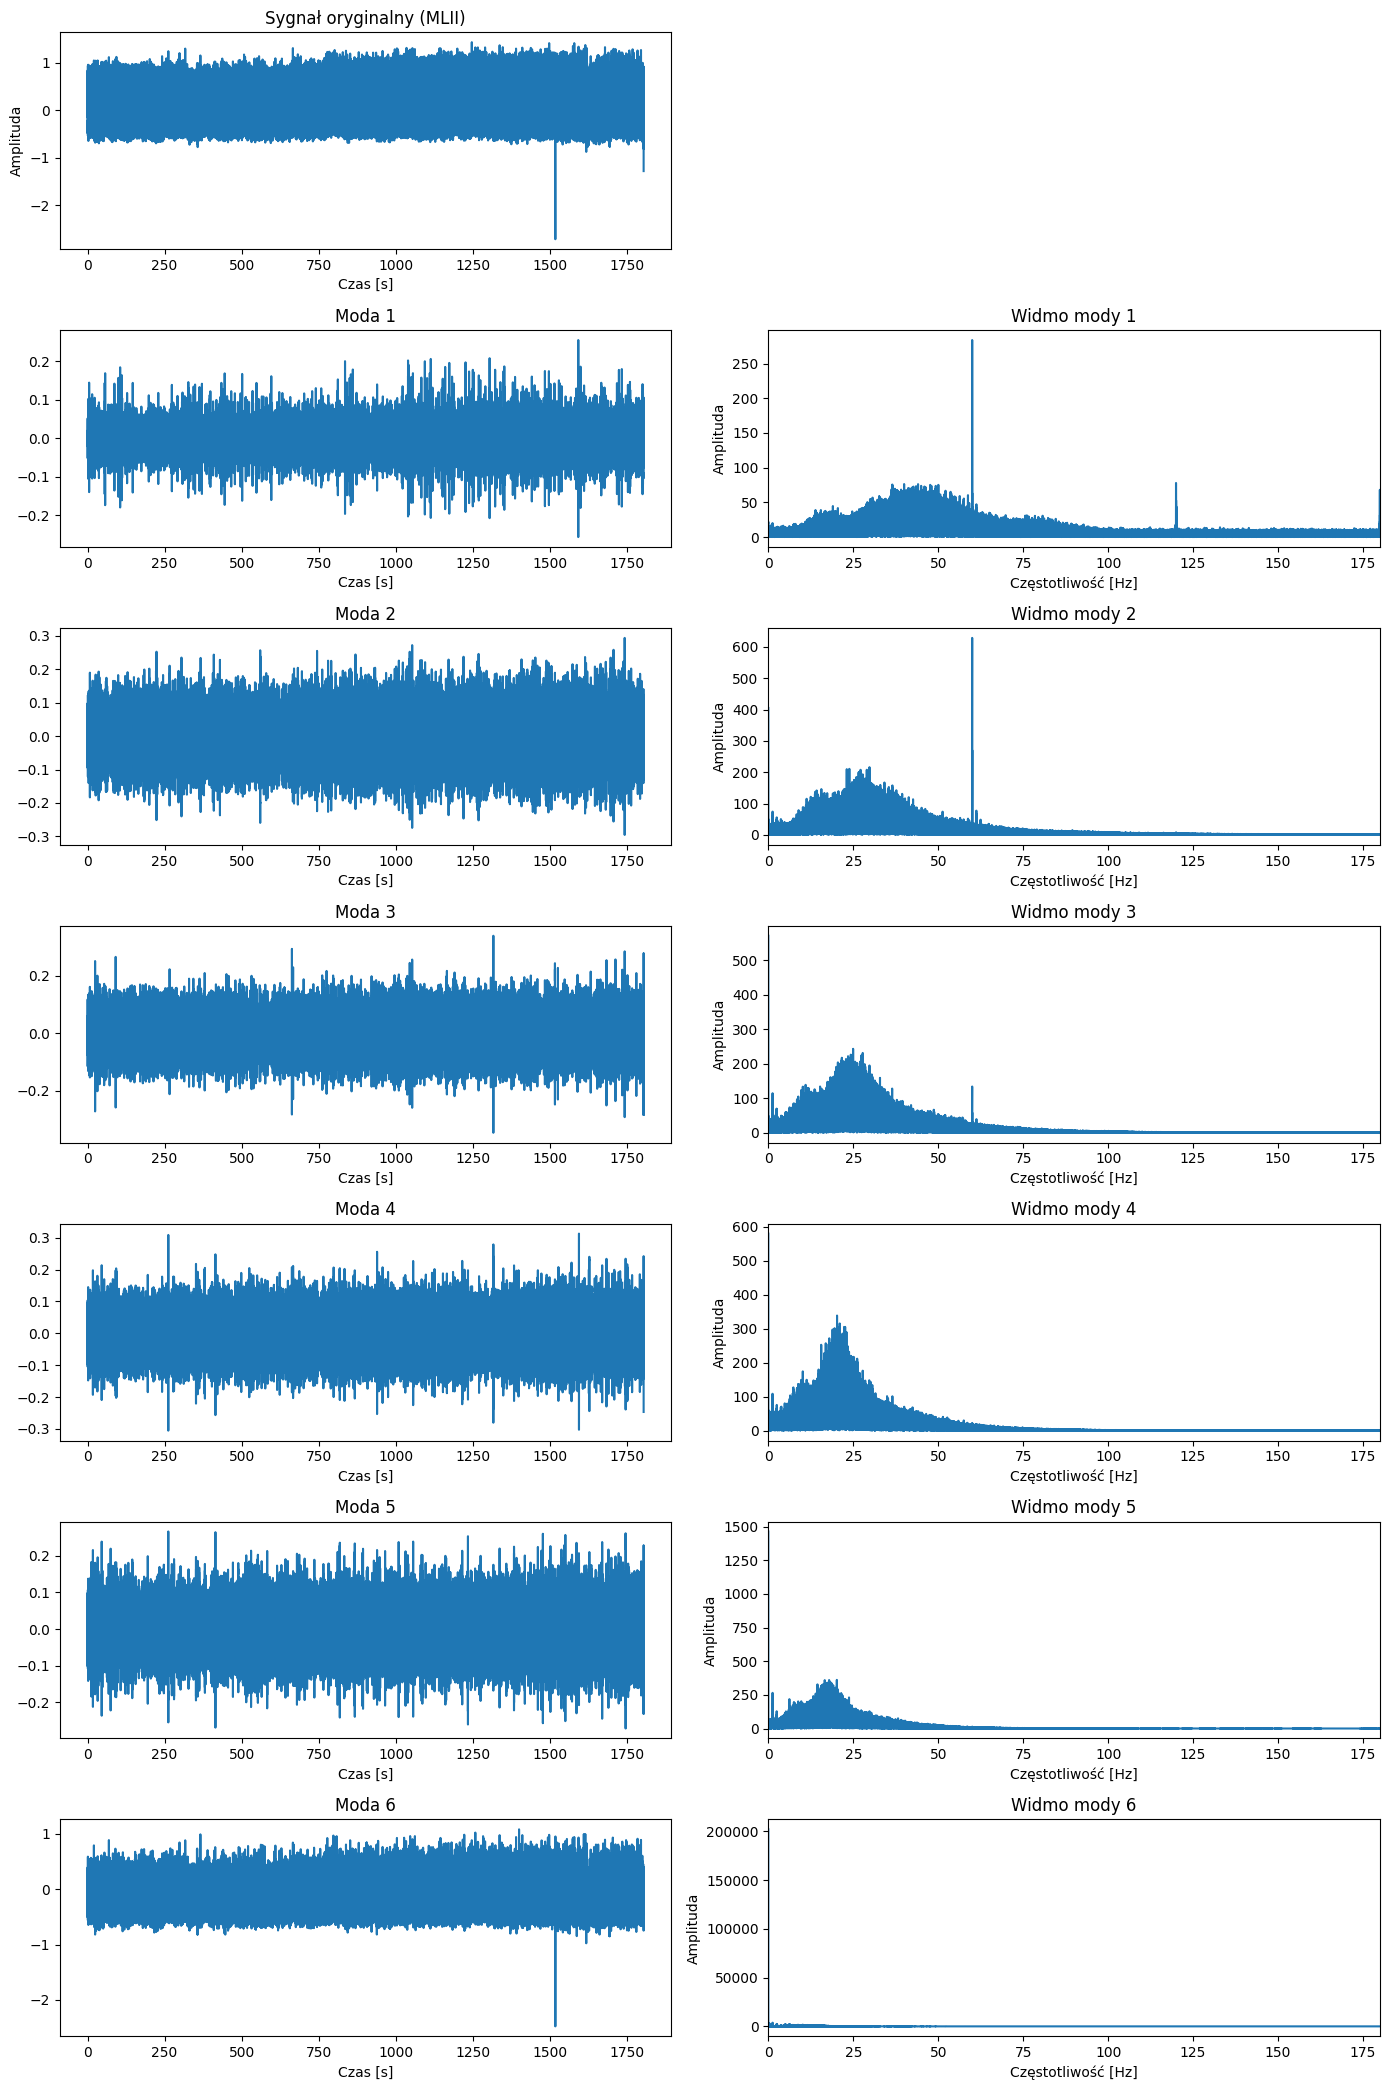

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyEMD import EMD
from scipy.fft import rfft, rfftfreq

df = pd.read_csv("sygnal_EKG.csv", sep=';')

time = df['time_ms'].values / 1000.0  # zamiana ms na sekundy
signal = df['MLII'].values
fs = 1 / np.mean(np.diff(time))  # wylicz częstotliwość próbkowania

print(f"Częstotliwość próbkowania: {fs:.2f} Hz")

emd = EMD()
IMFs = emd.emd(signal, time, max_imf=5)
n_imfs = IMFs.shape[0]

fig, axs = plt.subplots(n_imfs + 1, 2, figsize=(14, 3 * (n_imfs + 1)))

axs[0, 0].plot(time, signal)
axs[0, 0].set_title("Sygnał oryginalny (MLII)")
axs[0, 0].set_xlabel("Czas [s]")
axs[0, 0].set_ylabel("Amplituda")
axs[0, 1].axis("off")

# mody
for i in range(n_imfs):
    imf = IMFs[i]
    axs[i + 1, 0].plot(time, imf)
    axs[i + 1, 0].set_title(f"Moda {i + 1}")
    axs[i + 1, 0].set_xlabel("Czas [s]")

    freqs = rfftfreq(len(imf), d=1/fs)
    spectrum = np.abs(rfft(imf))

    axs[i + 1, 1].plot(freqs, spectrum)
    axs[i + 1, 1].set_title(f"Widmo mody {i + 1}")
    axs[i + 1, 1].set_xlabel("Częstotliwość [Hz]")
    axs[i + 1, 1].set_ylabel("Amplituda")
    axs[i + 1, 1].set_xlim(0, fs / 2)

plt.tight_layout()
plt.show()
